In [19]:
import pandas as pd
import numpy as np
import time

### Generate sample data for the example

Lets create a dataframe with two columns: 'pmid' and 'embedding'. The 'pmid' column will contain the PubMed ID of the article and the 'embedding' column will contain the embedding of the article. Ofcourse, these are randomly generated data for the sake of the example.

In [25]:
embed_size = 1204
num_emebddings  = 32000
embeddings = np.random.rand(num_emebddings, embed_size)
pmids = np.random.randint(0, num_emebddings, num_emebddings)

df = pd.DataFrame(pmids, columns=['pmid'])
df['embeddings'] = df['pmid'].apply(lambda x: embeddings[x])

print(df.head())
print(df.info())


    pmid                                         embeddings
0  27675  [0.6137103159251731, 0.08219436444088113, 0.97...
1   9357  [0.9323475771653554, 0.3659900678206477, 0.627...
2  19256  [0.405924000445941, 0.9002775932229072, 0.4187...
3  22022  [0.23709499138024348, 0.7560790980508381, 0.18...
4  18330  [0.4682921817044934, 0.61345144726754, 0.87852...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32000 entries, 0 to 31999
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   pmid        32000 non-null  int64 
 1   embeddings  32000 non-null  object
dtypes: int64(1), object(1)
memory usage: 500.1+ KB
None


### 1. df.iterrows() (Very slow)

As per pandas documentation it converts rows into series object. This conversion is very slow and is not recommended for large dataframes.

In [26]:
start_iterrows = time.time()
mean_list = []
for index, row in df.iterrows():
    mean = np.mean(row['embeddings'])
    mean_list.append(mean)
time_taken_iterrows = time.time() - start_iterrows
print(f'Time taken for iterrows: {time_taken_iterrows} seconds')

Time taken for iterrows: 2.069096803665161


### 2. using .loc or .iloc 



In [27]:
start_loc = time.time()
mean_list = []
for index in range(len(df)):
    mean = np.mean(df.loc[index, 'embeddings'])
    mean_list.append(mean)
    
time_taken_loc = time.time() - start_loc
print(f'Time taken for loc: {time_taken_loc}')

start_iloc = time.time()
mean_list = []
for index in range(len(df)):
    mean = np.mean(df.iloc[index, 1])
    mean_list.append(mean)
    
time_taken_iloc = time.time() - start_iloc
print(f'Time taken for iloc: {time_taken_iloc} seconds')


Time taken for loc: 0.6634902954101562
Time taken for iloc: 1.4806172847747803


### 3. using .itertuples()

In this method, rows are converted into tuples, which is faster than converting into series object in case of iterrows().

In [28]:
start_itertuples = time.time()
mean_list = []
for row in df.itertuples():
    mean = np.mean(row.embeddings)
    mean_list.append(mean)

time_taken_itertuples = time.time() - start_itertuples
print(f'Time taken for itertuples: {time_taken_itertuples} seconds')

Time taken for itertuples: 0.30716872215270996


### 4. using vectorized operations

The difference between adding two numbers or two vectors is not significant for a CPU, which should speed things up.

Pandas takes care of vectorizing our data with an optimized C code using contiguous memory blocks.

This is solution is very intutive to think about, but it is not always possible to vectorize the operations.

In [32]:
start_vectorized = time.time()
mean_list = np.mean(df['embeddings'].values, axis=0).tolist()

time_taken_vectorized = time.time() - start_vectorized
print(f'Time taken for vectorized: {time_taken_vectorized} seconds')

Time taken for vectorized: 0.06318378448486328 seconds


### using .to_numpy() method

This method is used to convert dataframe into numpy array. This is the fastest method to iterate over dataframe.

In [40]:
start_numpy = time.time()
mean_list = []

for pmid, embed in df.to_numpy():
    mean = np.mean(embed)
    mean_list.append(mean)

time_taken_numpy = time.time() - start_numpy
print(f'Time taken for numpy: {time_taken_numpy} seconds')

Time taken for numpy: 0.33736491203308105 seconds


### numpy vectorized operations

In some cases, the df converted to numpy array can be used for vectorized operations, which totally depends on what operations we are performing on the dataframe.

This is good to know because it is a very fast method to iterate over dataframe and it is very easy to implement.

In [41]:
start_numpy_vectorized = time.time()
mean_list = np.mean(df.to_numpy()[:, 1], axis=0).tolist()
time_taken_numpy_vectorized = time.time() - start_numpy_vectorized
print(f'Time taken for numpy vectorized: {time_taken_numpy_vectorized} seconds')

Time taken for numpy vectorized: 0.06090807914733887 seconds


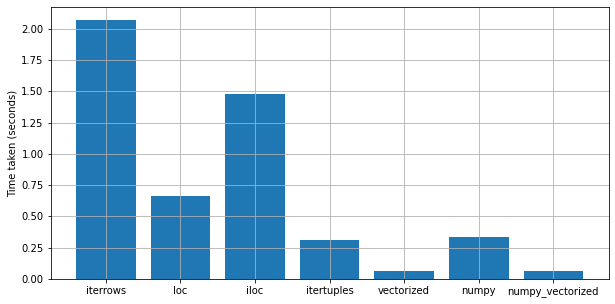

In [47]:
# plot the results in a bar chart
import matplotlib.pyplot as plt

data = {'iterrows': time_taken_iterrows,
        'loc': time_taken_loc,
        'iloc': time_taken_iloc,
        'itertuples': time_taken_itertuples,
        'vectorized': time_taken_vectorized,
        'numpy': time_taken_numpy,
        'numpy_vectorized': time_taken_numpy_vectorized}

plt.figure(figsize=(10, 5))
plt.bar(range(len(data)), list(data.values()), align='center')
plt.xticks(range(len(data)), list(data.keys()))
plt.ylabel('Time taken (seconds)')
plt.grid()
plt.show()

### conclusion

Here, the clear winner is vectorized operations using numpy array. But it is not always possible to vectorize the operations and it totally depends on the operations we are performing on the dataframe.

If we omit the vectorized operations, then the fastest method is to convert dataframe into numpy array using .to_numpy() method.